In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [4]:
assignments_df = pd.read_csv("hpc_search/data/assignments.csv")
print(f"Total assignments: {len(assignments_df)}")
print(f"Unique clusters  : {assignments_df['cluster_id'].nunique()}")
assignments_df.head()

Total assignments: 2854639
Unique clusters  : 100


,molecule_index,cluster_id
0,0,85
1,1,40
2,2,97
3,3,80
4,4,98


In [6]:
N_TOTAL = len(assignments_df)
SAMPLE_SIZE = 50000

# Sample indices evenly
sample_idx = np.linspace(0, N_TOTAL - 1, SAMPLE_SIZE, dtype=int)

# Load fingerprints for sampled indices only
all_fps = np.fromfile(
    "hpc_search/data/chembl_fingerprints.bin",
    dtype=np.uint64
).reshape(N_TOTAL, 32)

# Convert uint64 → individual bits (2048 per molecule)
def unpack_fingerprints(packed):
    # packed: (N, 32) uint64 → (N, 2048) uint8
    result = np.unpackbits(
        packed.view(np.uint8).reshape(packed.shape[0], -1),
        axis=1
    )
    return result[:, :2048]

sampled_packed = all_fps[sample_idx]
sampled_fps = unpack_fingerprints(sampled_packed)
sampled_labels = assignments_df['cluster_id'].values[sample_idx]

print(f"Sampled fingerprints shape : {sampled_fps.shape}")
print(f"Sampled labels shape       : {sampled_labels.shape}")

Sampled fingerprints shape : (50000, 2048)
Sampled labels shape       : (50000,)


In [7]:
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(sampled_fps)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"2D coords shape: {coords_2d.shape}")

Running PCA...
Explained variance ratio: [0.02036143 0.02001727]
2D coords shape: (50000, 2)


C:\Users\snrup\AppData\Local\Temp\ipykernel_25928\3408714899.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 100)


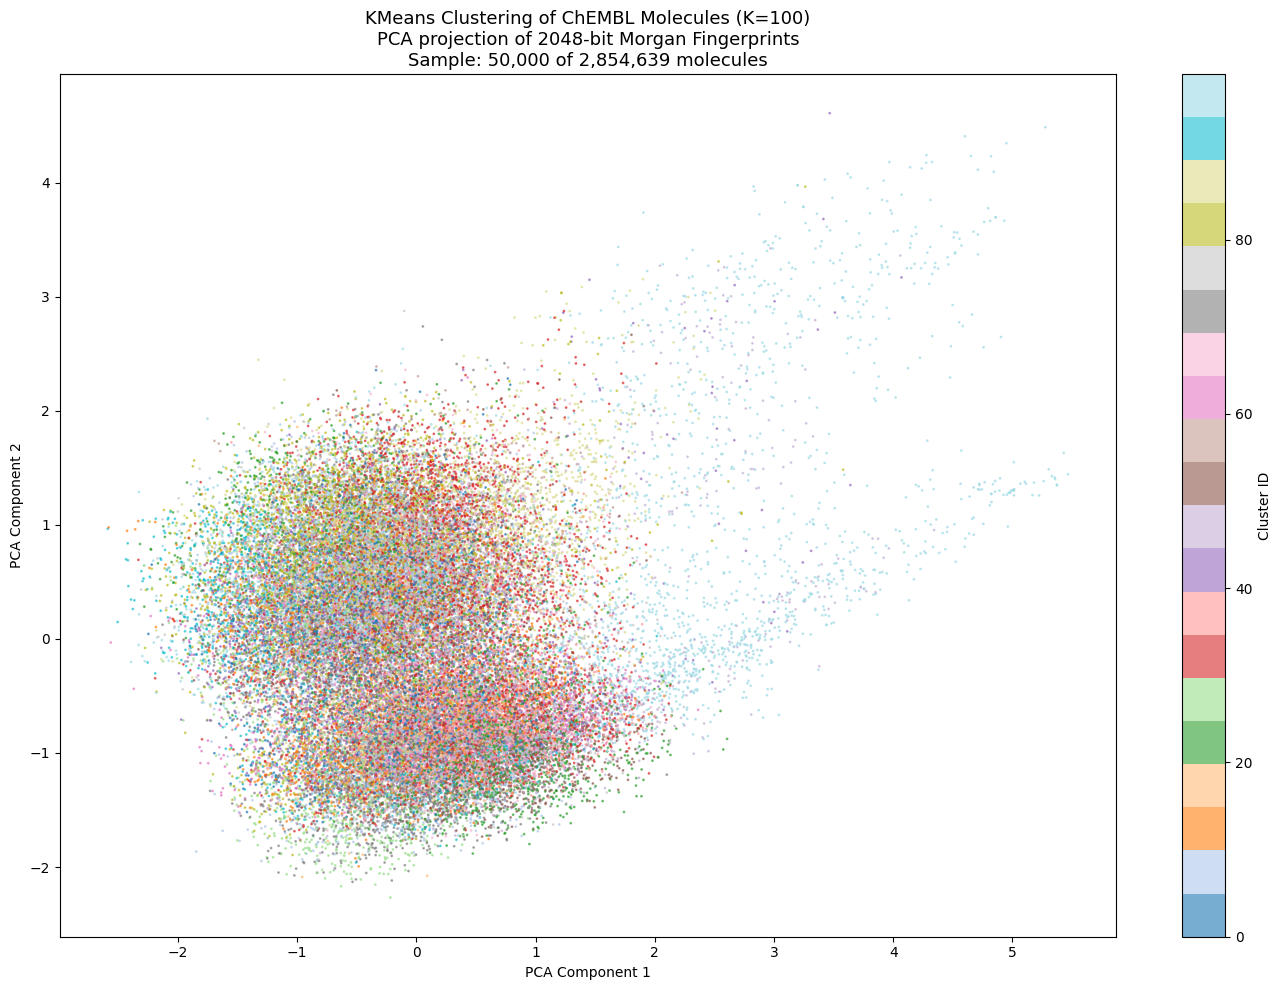

Plot saved!


In [8]:
plt.figure(figsize=(14, 10))

# Use a colormap with 100 distinct colors
cmap = plt.cm.get_cmap('tab20', 100)

scatter = plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=sampled_labels,
    cmap=cmap,
    s=1, # small dot size since 50K points
    alpha=0.6
)

plt.colorbar(scatter, label='Cluster ID')
plt.title(f'KMeans Clustering of ChEMBL Molecules (K=100)\nPCA projection of 2048-bit Morgan Fingerprints\nSample: {SAMPLE_SIZE:,} of {N_TOTAL:,} molecules', 
          fontsize=13)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()
print("Plot saved!")

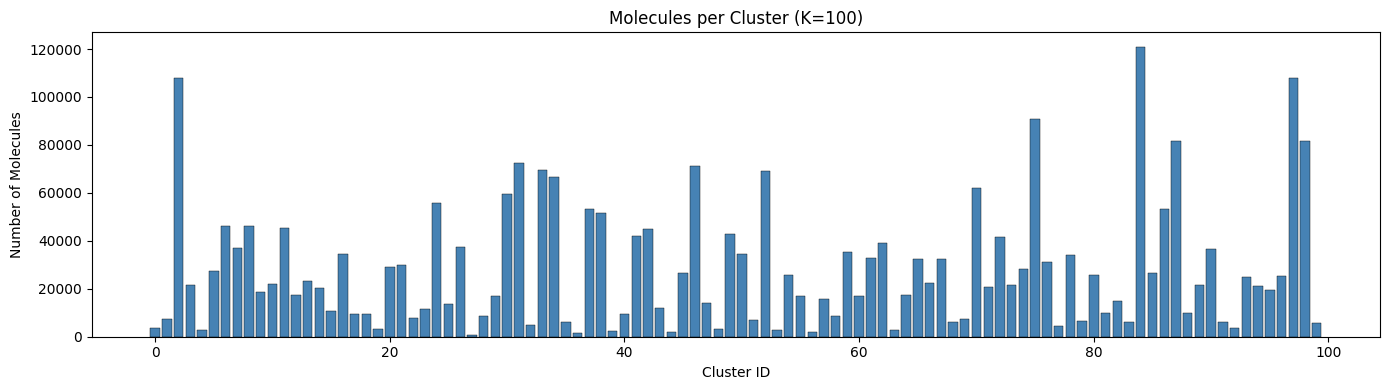

Largest cluster  : 120,919 molecules
Smallest cluster : 525 molecules
Average cluster  : 28546 molecules


In [9]:
cluster_counts = assignments_df['cluster_id'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black', linewidth=0.3)
plt.title('Molecules per Cluster (K=100)')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Molecules')
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150)
plt.show()

print(f"Largest cluster  : {cluster_counts.max():,} molecules")
print(f"Smallest cluster : {cluster_counts.min():,} molecules")
print(f"Average cluster  : {cluster_counts.mean():.0f} molecules")

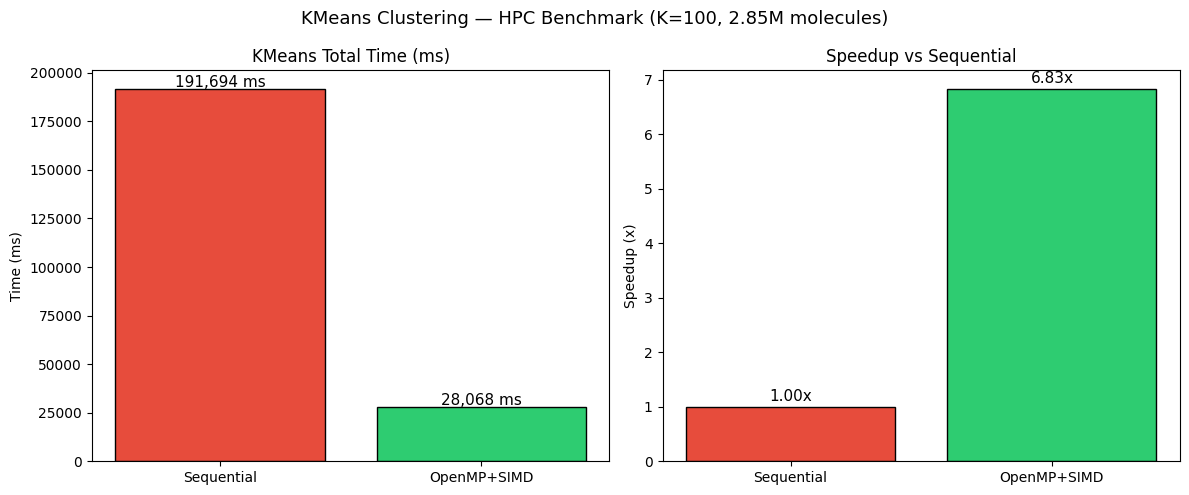

In [10]:
methods = ['Sequential', 'OpenMP+SIMD']
times   = [191694, 28068]
speedups = [1.0, 191694/28068]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Time comparison
ax1.bar(methods, times, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax1.set_title('KMeans Total Time (ms)')
ax1.set_ylabel('Time (ms)')
for i, v in enumerate(times):
    ax1.text(i, v + 1000, f'{v:,} ms', ha='center', fontsize=11)

# Speedup
ax2.bar(methods, speedups, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax2.set_title('Speedup vs Sequential')
ax2.set_ylabel('Speedup (x)')
for i, v in enumerate(speedups):
    ax2.text(i, v + 0.1, f'{v:.2f}x', ha='center', fontsize=11)

plt.suptitle('KMeans Clustering — HPC Benchmark (K=100, 2.85M molecules)', fontsize=13)
plt.tight_layout()
plt.savefig('kmeans_benchmark.png', dpi=150)
plt.show()